<a href="https://colab.research.google.com/github/JoseTayllan/Perceptron-Simples/blob/main/Perceptron_Simples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***


Curso: GTI
***

Disciplina: IA aplicada

Professor(a): Jonas Augusto Kunzler

Aluno(a): José tayllan Pinto Almeida

Data: 10/03/2025

***
Descrição:

Este código implementa um Perceptron Simples utilizando Python e NumPy para classificar
pontos no plano cartesiano.

O algoritmo aprende a separar os pontos com base em uma reta
predefinida e ajusta seus pesos utilizando a regra de atualização do Perceptron.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Definir uma reta de separação (exemplo: y = 2x + 1)
def target_function(x):
    return 2 * x + 1

In [3]:
# Função de ativação degrau
def step_function(x):
    return 1 if x >= 0 else 0


In [6]:
def train_perceptron(X, y, weights, learning_rate=0.1, epochs=50):
    """
    Treina o Perceptron ajustando os pesos com base no erro.

    Parâmetros:
    - X: Dados de entrada com bias
    - y: Rótulos das classes
    - weights: Pesos iniciais
    - learning_rate: Taxa de aprendizado
    - epochs: Número de épocas

    Retorna:
    - Pesos ajustados
    """
    for epoch in range(epochs):
        for i in range(len(y)):
            x_i = X[i]
            y_pred = step_function(np.dot(x_i, weights))
            error = y[i] - y_pred
            weights += learning_rate * error * x_i  # Atualização dos pesos
    return weights

# Treinar o Perceptron
weights = train_perceptron(X_bias, y, weights)

In [7]:
def predict(X, weights):
    """
    Faz previsões usando o Perceptron treinado.

    Parâmetros:
    - X: Dados de entrada
    - weights: Pesos treinados

    Retorna:
    - Array com as previsões
    """
    return np.array([step_function(np.dot(x, weights)) for x in X])


In [8]:
def plot_decision_boundary(weights):
    """Plota a fronteira de decisão do Perceptron"""
    x_vals = np.linspace(-10, 10, 100)
    y_vals = -(weights[0] + weights[1] * x_vals) / weights[2]  # y = (-bias - w1*x)/w2
    plt.plot(x_vals, y_vals, 'g--', label='Perceptron Boundary')


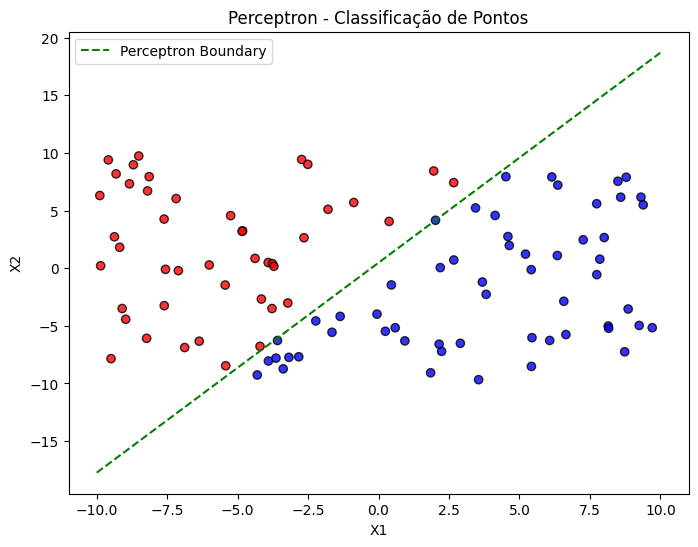

In [9]:

# Gerar dados aleatórios
np.random.seed(42)
n_samples = 100
X = np.random.uniform(-10, 10, (n_samples, 2))  # Pontos aleatórios no plano cartesiano



# Gerar rótulos baseados na reta de separação
y = np.where(X[:, 1] > target_function(X[:, 0]), 1, 0)

# Adicionar um bias aos dados
X_bias = np.c_[np.ones((n_samples, 1)), X]  # Adiciona uma coluna de 1s para o bias

# Inicializar pesos aleatórios
weights = np.random.rand(3)



# Treinar o Perceptron
weights = train_perceptron(X_bias, y, weights)


# Plotando os dados e a reta do Perceptron
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.8, edgecolors='k')



plot_decision_boundary(weights)
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.title("Perceptron - Classificação de Pontos")
plt.show()
